In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, auc
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('creditcard.csv')
df.dropna(inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"Fraud percentage: {df['Class'].value_counts()[1]/len(df)*100:.3f}%")

Dataset shape: (284807, 31)
Missing values: 0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.173%


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
)

In [ ]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fraud in train: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.3f}%)")
print(f"Fraud in test: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.3f}%)")

Training set: (199364, 30)
Test set: (85443, 30)
Fraud in train: 356 (0.179%)
Fraud in test: 136 (0.159%)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
print("\nApplying SMOTE for class imbalance...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)


Applying SMOTE for class imbalance...


In [ ]:
print(f"After SMOTE - Training set: {X_train_smote.shape}")
print(f"Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE - Training set: (398016, 30)
Class distribution after SMOTE:
Class
0    199008
1    199008
Name: count, dtype: int64


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}

In [ ]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train model
    model.fit(X_train_smote, y_train_smote)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    # Get confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    results[name] = {
        'model': model,
        'train_auc': train_auc,
        'test_auc': test_auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'y_test_pred': y_test_pred,
        'y_test_proba': y_test_proba,
        'cm': confusion_matrix(y_test, y_test_pred)
    }

    print(f"  Train AUC: {train_auc:.4f}")
    print(f"  Test AUC: {test_auc:.4f}")
    print(f"  Sensitivity (catch fraud): {sensitivity:.4f}")
    print(f"  Specificity (minimize false alarms): {specificity:.4f}")



Training Logistic Regression...
  Train AUC: 0.9876
  Test AUC: 0.9812
  Sensitivity (catch fraud): 0.9338
  Specificity (minimize false alarms): 0.9733

Training Random Forest...
  Train AUC: 1.0000
  Test AUC: 0.9851
  Sensitivity (catch fraud): 0.8676
  Specificity (minimize false alarms): 0.9998

Training Gradient Boosting...
  Train AUC: 0.9981
  Test AUC: 0.9863
  Sensitivity (catch fraud): 0.9265
  Specificity (minimize false alarms): 0.9873

Training XGBoost...
  Train AUC: 1.0000
  Test AUC: 0.9893
  Sensitivity (catch fraud): 0.8676
  Specificity (minimize false alarms): 0.9994


In [ ]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train AUC': [results[m]['train_auc'] for m in results.keys()],
    'Test AUC': [results[m]['test_auc'] for m in results.keys()],
    'Sensitivity': [results[m]['sensitivity'] for m in results.keys()],
    'Specificity': [results[m]['specificity'] for m in results.keys()]
})




# Find best model
best_model_name = results_df.loc[results_df['Test AUC'].idxmax(), 'Model']
best_auc = results_df['Test AUC'].max()

print(f"\n BEST MODEL: {best_model_name}")
print(f"  Test AUC: {best_auc:.4f}")
print(f"  Sensitivity: {results[best_model_name]['sensitivity']:.4f}")
print(f"  Specificity: {results[best_model_name]['specificity']:.4f}")


 BEST MODEL: XGBoost
  Test AUC: 0.9893
  Sensitivity: 0.8676
  Specificity: 0.9994


  ✓ Saved: roc_curves.png


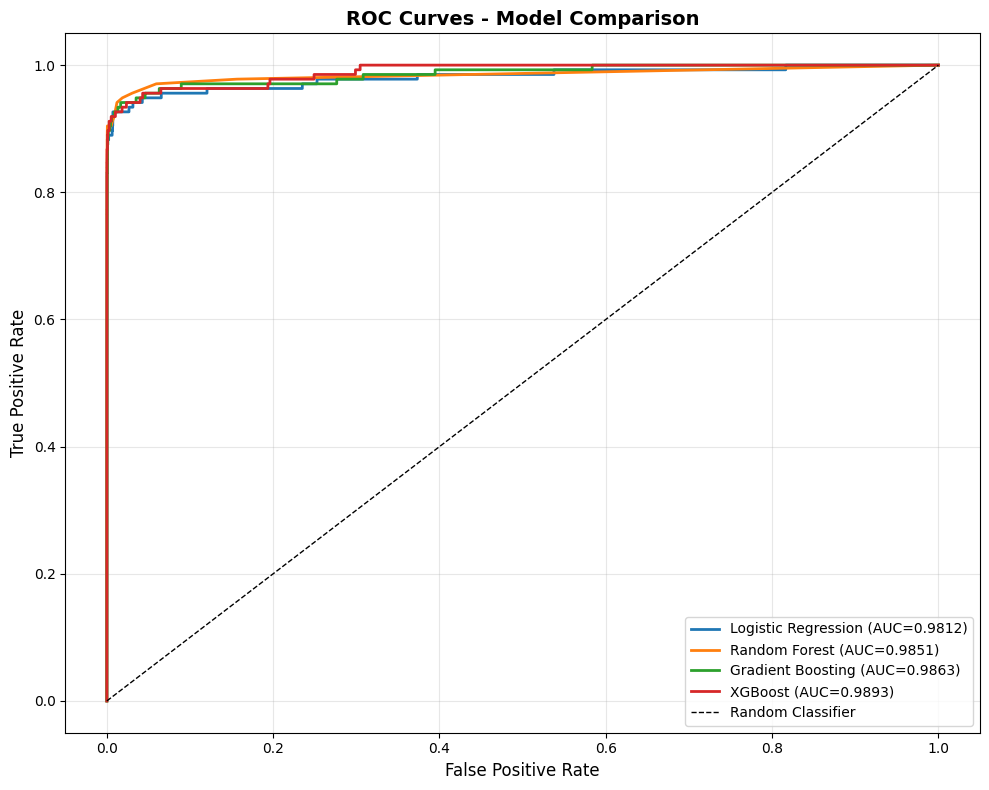

In [ ]:
plt.figure(figsize=(10, 8))
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_test_proba'])
    auc_score = results[name]['test_auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
print(" Saved: roc_curves.png")
plt.show()

  ✓ Saved: confusion_matrices.png


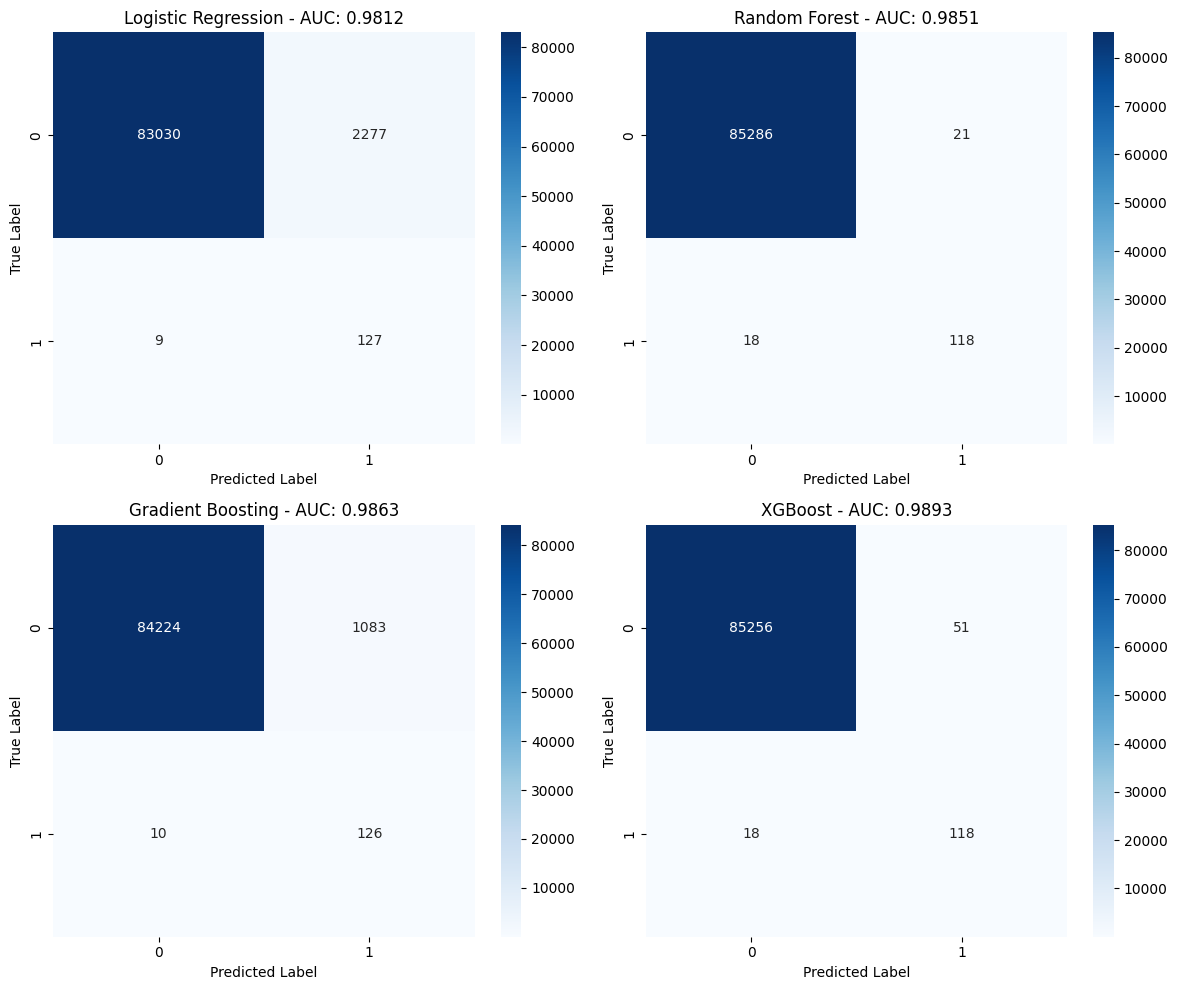

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, name in enumerate(list(results.keys())[:4]):
    cm = results[name]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} - AUC: {results[name]["test_auc"]:.4f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print("   Saved: confusion_matrices.png")
plt.show()

  ✓ Saved: model_comparison.png


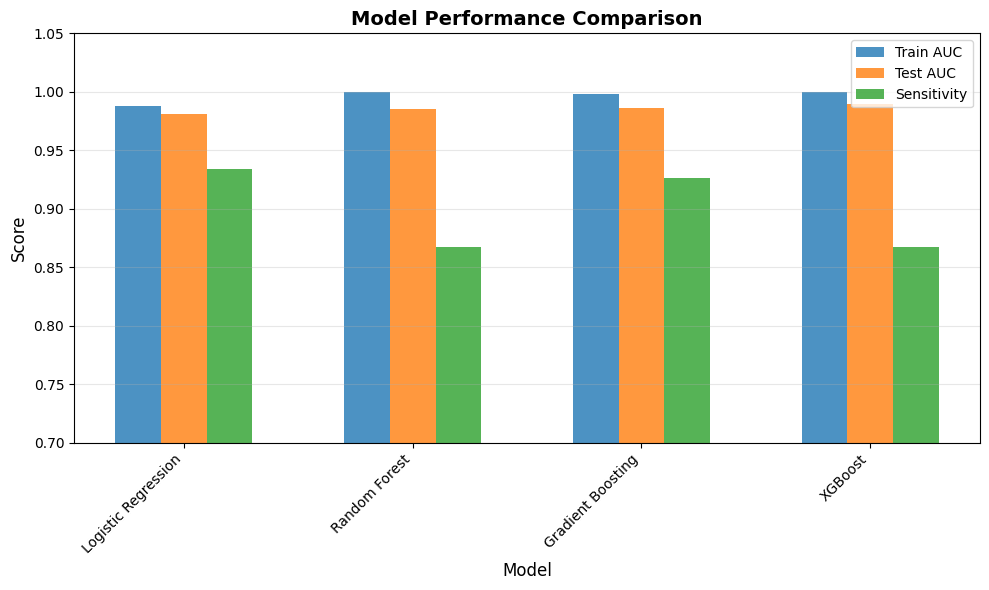

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.2

ax.bar(x - width, results_df['Train AUC'], width, label='Train AUC', alpha=0.8)
ax.bar(x, results_df['Test AUC'], width, label='Test AUC', alpha=0.8)
ax.bar(x + width, results_df['Sensitivity'], width, label='Sensitivity', alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0.7, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("   Saved: model_comparison.png")
plt.show()

  ✓ Saved: class_distribution.png


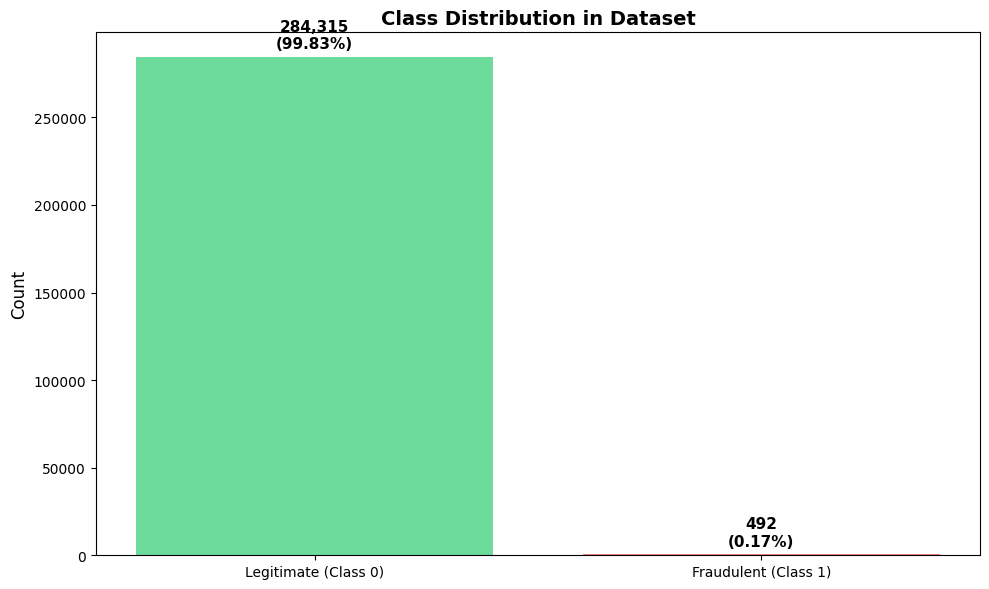

In [ ]:
plt.figure(figsize=(10, 6))
class_counts = y.value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(['Legitimate (Class 0)', 'Fraudulent (Class 1)'], class_counts.values, color=colors, alpha=0.7)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
for i, v in enumerate(class_counts.values):
    pct = v / len(y) * 100
    plt.text(i, v + 5000, f'{v:,}\n({pct:.2f}%)', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
print("   Saved: class_distribution.png")
plt.show()

In [ ]:
import os


# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save best model
import pickle
best_model = results[best_model_name]['model']
with open(f'models/{best_model_name.lower().replace(" ", "_")}_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"   Saved: {best_model_name.lower().replace(' ', '_')}_model.pkl")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("   Saved: scaler.pkl")


  ✓ Saved: model_results.csv
  ✓ Saved: xgboost_model.pkl
  ✓ Saved: scaler.pkl


In [ ]:

print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")

print(classification_report(y_test, results[best_model_name]['y_test_pred'],
                          target_names=['Legitimate', 'Fraudulent']))


print(f"\nBest Model: {best_model_name}")
print(f"Test AUC: {best_auc:.4f}")


DETAILED CLASSIFICATION REPORT - XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     85307
  Fraudulent       0.70      0.87      0.77       136

    accuracy                           1.00     85443
   macro avg       0.85      0.93      0.89     85443
weighted avg       1.00      1.00      1.00     85443

  - CSV: model_results.csv

Best Model: XGBoost
Test AUC: 0.9893
